# 02 · Quality control and normalisation

In this notebook you will:

- drop cells the segmentation cannot be trusted on  *(this is Part 3's memory peak)*
- see why intensities from different imaging rounds are **not comparable**
- find the one condition that behaves like an outlier, before it wrecks an embedding
- aggregate to the **well**, which is the real replicate unit
- normalise against the DMSO controls, within timepoint

The theme chapters all start from the object this notebook writes.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc

sys.path.insert(0, str(Path.cwd().parents[2] / "src"))

from mcs2026 import panels, plotting
from mcs2026.config import H5AD_SLIM

plotting.set_style()
pd.set_option("display.width", 140)

adata = sc.read_h5ad(H5AD_SLIM)
adata

AnnData object with n_obs × n_vars = 44800 × 2587
    obs: 'label', 'well_name', 'ROI', 'is_border_internal', 'is_border_external', 'Organoid_ID', 'timepoint_h', 'condition', 'condition_code', 'well', 'row', 'column'
    var: 'family', 'statistic', 'channel', 'round', 'marker', 'species', 'intensity_threshold', 'haralick_threshold', 'failed', 'is_reference', 'is_structural', 'theme'
    uns: 'is_fixture', 'provenance'

## 1. Cells you should not trust

The feature table ships two flags from the segmentation step. `is_border_external`
marks cells touching the edge of an imaged field; `is_border_internal` marks cells on
an internal boundary between fields.

A cell cut off by the edge of the image has a truncated area, a truncated perimeter and
a mean intensity computed over only part of itself. Every one of its features is wrong
in a direction that depends on how much was cut off.

In [2]:
flags = adata.obs[["is_border_external", "is_border_internal"]]
pd.DataFrame({
    "cells": flags.sum(),
    "fraction": (flags.sum() / len(flags)).map("{:.1%}".format),
})

,cells,fraction
is_border_external,5250,11.7%
is_border_internal,620,1.4%


Before dropping them, it is worth a look at *how* wrong they are — partly to justify
the decision, partly because "border cells are smaller" is the kind of claim that
should be checked rather than assumed.

In [3]:
area_column = adata.var.index[
    (adata.var.family == "Morphology") & (adata.var.statistic == "area")
][0]
area = np.asarray(adata[:, area_column].X).ravel()

comparison = pd.DataFrame({"area": area, "border": adata.obs.is_border_external.values})
comparison.groupby("border")["area"].describe()[["count", "mean", "50%"]]

,count,mean,50%
border,,,
False,39550.0,4464.972168,3225.0
True,5250.0,4326.273438,3067.5


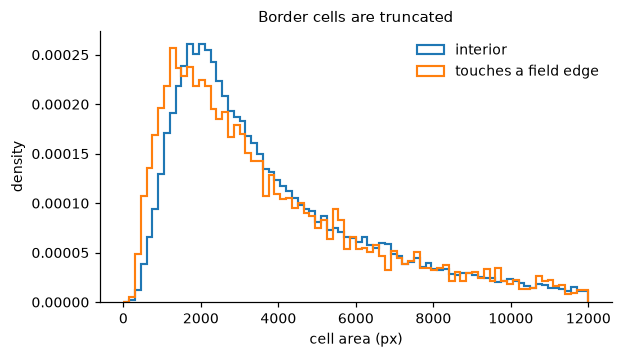

In [4]:
fig, ax = plt.subplots(figsize=(6, 3.2))
for is_border, label in [(False, "interior"), (True, "touches a field edge")]:
    ax.hist(comparison.loc[comparison.border == is_border, "area"], bins=80,
            range=(0, 12000), histtype="step", density=True, label=label, linewidth=1.4)
ax.set(xlabel="cell area (px)", ylabel="density", title="Border cells are truncated")
ax.legend()

In [5]:
clean = adata[~adata.obs.is_border_external.values].copy()
print(f"{adata.n_obs:,} cells -> {clean.n_obs:,} after dropping external border cells "
      f"({1 - clean.n_obs / adata.n_obs:.1%} removed)")

# This line is the memory peak of the whole of Part 3: for a moment `adata` and `clean`
# both exist, which is roughly 1.9x the slim table. If your session is tight, free the
# original as soon as you no longer need it.
#
#     import gc; del adata; gc.collect()
#
# We keep `adata` here because exercise 1 compares against it.

44,800 cells -> 39,550 after dropping external border cells (11.7% removed)


:::{note}
We keep the internal-border cells. They sit on a seam between two imaged fields of the
same well, where the image is still complete — the flag marks a stitching boundary, not
a truncated cell. Dropping them too is defensible; dropping them *without saying so* is
not.
:::

## 2. Intensities are not comparable across rounds

Chapter 01 found that DAPI — the same stain, on the same nuclei, every round — moves by
more than an order of magnitude across the experiment. Here is what that means for the
markers.

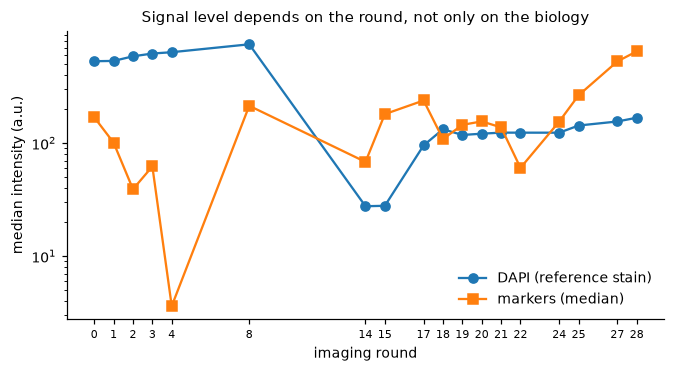

In [6]:
dapi_columns = adata.var.index[
    (adata.var.channel == "DAPI") & (adata.var.statistic == "mean_intensity")
]
dapi_columns = adata.var.loc[dapi_columns].sort_values("round").index

dapi = pd.Series(
    np.median(np.asarray(clean[:, list(dapi_columns)].X), axis=0),
    index=clean.var.loc[dapi_columns, "round"].astype(int).values,
    name="median DAPI",
)

markers = clean.var[
    (clean.var.family == "Intensity")
    & (clean.var.statistic == "mean_intensity")
    & clean.var.marker.notna()
    & (clean.var.marker != "DAPI")
    & (~clean.var.failed)
]
marker_median = pd.Series(
    np.median(np.asarray(clean[:, list(markers.index)].X), axis=0),
    index=markers["round"].astype(int).values,
).groupby(level=0).median()

fig, ax = plt.subplots(figsize=(7, 3.4))
ax.plot(dapi.index, dapi.values, marker="o", label="DAPI (reference stain)")
ax.plot(marker_median.index, marker_median.values, marker="s", label="markers (median)")
ax.set(xlabel="imaging round", ylabel="median intensity (a.u.)", yscale="log",
       title="Signal level depends on the round, not only on the biology")
ax.set_xticks(dapi.index)
ax.tick_params(axis="x", labelsize=7)
ax.legend()

The nuclei did not change between rounds. The measurement did.

So a heatmap that puts a round-2 marker next to a round-27 marker, or a PCA over the
whole panel, is partly ranking markers by *when they were imaged*. Two things follow:

- **compare a marker to itself across conditions**, never one marker's absolute level
  to another's;
- **centre every marker on its own controls**, which is what section 5 does.

## 3. Position effects

Condition and plate position are confounded by design: each condition always sits in
the same rows. So a row-wise artefact would be indistinguishable from a treatment
effect — *except* in the control wells, which appear in every row at a fixed treatment.
DMSO is the readout for plate position.

In [7]:
def well_means(data, columns):
    """Mean of each column per well -- the well is the replicate unit."""
    frame = pd.DataFrame(
        np.asarray(data[:, list(columns)].X),
        columns=[f"{data.var.loc[c, 'marker']}" for c in columns],
    )
    frame["well"] = data.obs.well.astype(str).values
    frame["condition"] = data.obs.condition.astype(str).values
    # NOTE: timepoint_h is an ordered categorical, which is right for plotting and
    # wrong for arithmetic -- pandas refuses to subtract categoricals. Cast to int.
    frame["timepoint"] = data.obs.timepoint_h.astype(int).values
    return frame.groupby(["condition", "timepoint", "well"], observed=True).mean().reset_index()

marker_columns = list(markers.index)
wells = well_means(clean, marker_columns)
wells["row"] = wells.well.str[0]
wells["column"] = wells.well.str[1:].astype(int)
print(f"{len(wells)} wells x {len(marker_columns)} markers")
wells.iloc[:4, :6]

224 wells x 38 markers


,condition,timepoint,well,beta-Catenin,Foxo3a,FGFR1
0,Cycloheximide,36,E02,276.104187,55.679802,50.712421
1,Cycloheximide,36,H04,273.988983,49.441422,59.108860
2,Cycloheximide,36,J05,275.937653,55.050083,53.474682
3,Cycloheximide,48,E08,252.879608,38.160900,54.865719


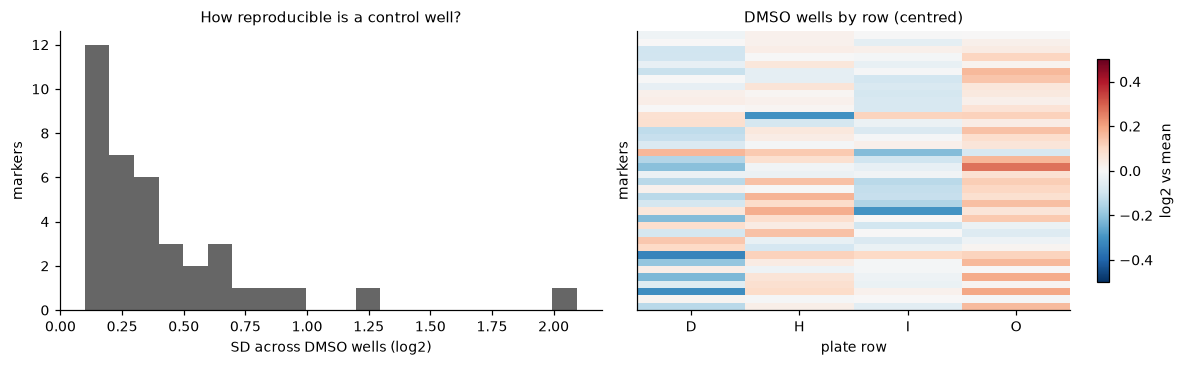

In [8]:
controls = wells[wells.condition == "DMSO"]
names = [clean.var.loc[c, "marker"] for c in marker_columns]
control_variation = np.log2(controls[names] + 1).std()

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
axes[0].hist(control_variation, bins=20, color="0.4")
axes[0].set(xlabel="SD across DMSO wells (log2)", ylabel="markers",
            title="How reproducible is a control well?")
by_row = np.log2(controls.set_index("row")[names] + 1).groupby(level=0).mean()
im = axes[1].imshow((by_row - by_row.mean()).T, aspect="auto", cmap="RdBu_r",
                    vmin=-0.5, vmax=0.5)
axes[1].set(xticks=range(len(by_row)), xticklabels=by_row.index,
            yticks=[], ylabel="markers", xlabel="plate row",
            title="DMSO wells by row (centred)")
fig.colorbar(im, ax=axes[1], shrink=0.8, label="log2 vs mean")
fig.tight_layout()

In [9]:
print(f"median control-well SD: {control_variation.median():.3f} log2 "
      f"({2 ** control_variation.median() - 1:.1%} on the linear scale)")
print(f"noisiest markers:\n{control_variation.nlargest(4).round(3).to_string()}")

median control-well SD: 0.299 log2 (23.0% on the linear scale)
noisiest markers:
GATA4         2.095
E-cadherin    1.273
LAMP1         0.967
p21           0.804


That median SD is the **yardstick**. An effect of 0.2 log2 is within the noise of two
control wells; an effect of 1.5 log2 is not. Every claim in the theme chapters is made
against this number, not against a p-value alone.

Note that the yardstick is *per marker*, not global. A handful of markers are far
noisier than the rest — usually the dimly expressed ones, where a small absolute
difference is a large relative one, and where the antibody has less to work with. For
those, only a very large shift means anything, and scaling each marker by **its own**
control SD (section 5) is what keeps them from either shouting or being ignored.

## 4. One condition is an outlier

Before normalising, look at the conditions as a whole. Unsupervised methods are
obedient: hand them one sample that is different from everything else and they will
spend their first component describing it.

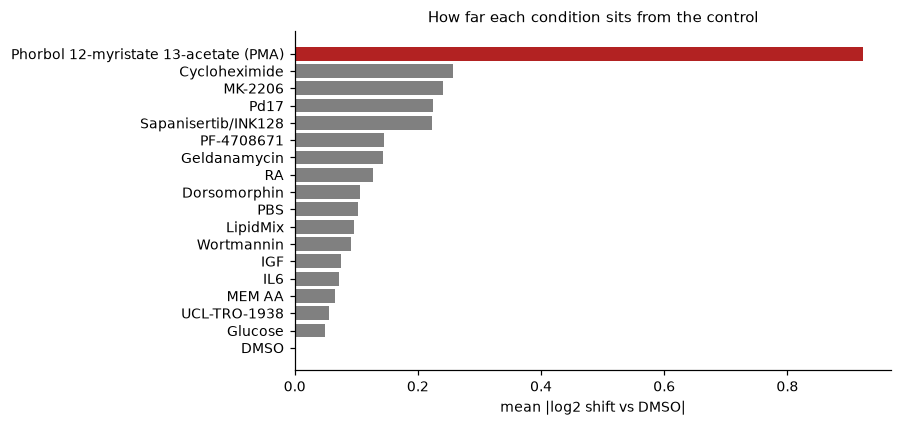

In [10]:
logged = np.log2(wells[names] + 1)
centred = logged - logged[wells.condition == "DMSO"].mean()
per_condition = centred.groupby(wells.condition).mean()
spread = per_condition.abs().mean(axis=1).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 4))
colors = ["firebrick" if v == spread.index[0] else "0.5" for v in spread.index]
ax.barh(range(len(spread)), spread.values, color=colors)
ax.set(yticks=range(len(spread)), yticklabels=spread.index, xlabel="mean |log2 shift vs DMSO|",
       title="How far each condition sits from the control")
ax.invert_yaxis()

In [11]:
spread.head(4).round(3)

condition
Phorbol 12-myristate 13-acetate (PMA)    0.923
Cycloheximide                            0.257
MK-2206                                  0.241
Pd17                                     0.225
dtype: float32

**PMA moves every marker, by a lot.** In units of control-well SD it shifts markers by
4 to 11 — that is not a pathway response, it is a different cell state. Phorbol esters
drive naive human ES cells out of pluripotency, so a wholesale change is biologically
reasonable; it is still an outlier statistically.

:::{important}
This is a decision, and it should be a conscious one:

- **keep PMA** and it dominates the first component of every embedding, so the plot
  describes PMA-vs-everything rather than the structure among the other 17;
- **drop PMA** and you lose a real, strong biological effect;
- **analyse it separately**, which is what this course does — the theme chapters flag
  it and the [projects](../../projects.md) can take it up.

What you must not do is leave it in silently and interpret component 1 as if it were
about subtle signaling differences.
:::

In [12]:
clean.obs["is_outlier_condition"] = clean.obs.condition.astype(str).eq(
    "Phorbol 12-myristate 13-acetate (PMA)"
)
clean.obs.is_outlier_condition.sum()

np.int64(1999)

## 5. Normalise

Three steps, in this order, and each for a stated reason.

**`log2`** — intensities are multiplicative and heavily right-skewed. A doubling should
look the same whether it is 100→200 or 1000→2000.

**Centre on DMSO, within timepoint** — this is the step that undoes the round-to-round
drift from section 2 and the plate effects from section 3, because the control wells
went through exactly the same rounds and sit in the same plate. Within *timepoint*,
because the controls themselves change over 36–84 h and we do not want to erase that.

**Scale by the control SD** — puts every marker in the same units: "how many
control-well standard deviations from the control mean". That is what makes a signaling
marker and an organelle marker comparable on one axis.

In [13]:
def normalise_to_controls(frame, feature_names, *, control="DMSO", within="timepoint"):
    """log2, centre on the control wells within each timepoint, scale by control SD.

    Returns the normalised frame. Units are control-well SDs, so a value of -2 means
    "two control standard deviations below the control mean at that timepoint".
    """
    logged = np.log2(frame[feature_names] + 1)
    out = logged.copy()
    is_control = frame[frame.columns[frame.columns.get_loc("condition")]] == control
    for _, index in frame.groupby(within, observed=True).groups.items():
        block = logged.loc[index]
        reference = block[is_control.loc[index]]
        out.loc[index] = (block - reference.mean()) / reference.std().replace(0, np.nan)
    return out

normalised = normalise_to_controls(wells, names)
normalised.insert(0, "condition", wells.condition.values)
normalised.insert(1, "timepoint", wells.timepoint.values)
normalised.insert(2, "well", wells.well.values)
normalised.iloc[:4, :7].round(2)

,condition,timepoint,well,beta-Catenin,Foxo3a,FGFR1,Nanog
0,Cycloheximide,36,E02,-9.80,-0.48,-3.03,-0.38
1,Cycloheximide,36,H04,-10.17,-2.04,-0.32,0.49
2,Cycloheximide,36,J05,-9.83,-0.63,-2.09,-0.75
3,Cycloheximide,48,E08,-2.65,-2.07,-2.85,-0.83


In [14]:
# Check it worked: within each timepoint the control wells must now sit at mean 0
# and SD 1, because that is exactly what they were scaled by.
control_check = normalised[normalised.condition == "DMSO"]
pd.DataFrame({
    "mean": control_check.groupby("timepoint", observed=True)[names].mean().mean(axis=1),
    "SD": control_check.groupby("timepoint", observed=True)[names].std().mean(axis=1),
}).round(3)

,mean,SD
timepoint,,
36,0.0,1.0
48,0.0,1.0
60,-0.0,1.0
84,-0.0,1.0


## 6. Does a known answer come out?

The compounds were chosen to hit specific processes, so there is a prediction to test.
**Sapanisertib/INK128 inhibits mTOR**; mTORC1 activates S6 kinase, which phosphorylates
ribosomal protein S6. So INK128 should lower **p-S6**.

In [15]:
from scipy import stats

def compare_to_control(frame, marker, condition, control="DMSO"):
    rows = []
    for timepoint, block in frame.groupby("timepoint", observed=True):
        treated = block.loc[block.condition == condition, marker]
        reference = block.loc[block.condition == control, marker]
        rows.append({
            "timepoint": timepoint,
            "n_treated": len(treated), "n_control": len(reference),
            "shift (control SDs)": round(treated.mean() - reference.mean(), 2),
            "p (Mann-Whitney)": round(stats.mannwhitneyu(treated, reference).pvalue, 4),
        })
    return pd.DataFrame(rows)

compare_to_control(normalised, "p-S6", "Sapanisertib/INK128")

,timepoint,n_treated,n_control,shift (control SDs),p (Mann-Whitney)
0,36,3,5,-5.29,0.0357
1,48,3,5,-7.01,0.0357
2,60,3,5,-6.91,0.0357
3,84,3,5,-1.11,0.0357


In [16]:
compare_to_control(normalised, "p-S6", "MK-2206")

,timepoint,n_treated,n_control,shift (control SDs),p (Mann-Whitney)
0,36,3,5,-3.66,0.0357
1,48,3,5,-3.92,0.0357
2,60,3,5,-3.84,0.0357
3,84,3,5,-0.29,1.0000


Both inhibitors lower p-S6 at 36, 48 and 60 hours, by several control SDs, and the
effect fades by 84 h — the compound is used up, or the cells adapt. That is a real
result with the sign the pathway predicts.

:::{warning}
**Look at the p-values, not just the stars.** Every significant row above reads
`0.0357`, and that is not a coincidence: with 3 treated wells and 5 control wells there
are $\binom{8}{3} = 56$ ways to arrange the ranks, so the smallest two-sided p-value a
Mann-Whitney test can *ever* return here is $2/56 = 0.0357$.

No effect size, however enormous, can produce a smaller one. The p-value has hit the
floor imposed by the number of wells. This is what it means to say the replicate unit
is the well — and it is why the theme chapters report **effect sizes in control SDs**
first and p-values second.
:::

### The one that does not work

The obvious readout for an AKT inhibitor is phospho-AKT itself. Try it.

In [17]:
compare_to_control(normalised, "p-AKT", "MK-2206")

,timepoint,n_treated,n_control,shift (control SDs),p (Mann-Whitney)
0,36,3,5,-0.38,0.7857
1,48,3,5,-0.43,0.7857
2,60,3,5,-1.89,0.0714
3,84,3,5,-0.43,0.5714


Nothing. Nor for Wortmannin, nor INK128 — p-AKT barely moves for any of them.

This is not a bug in the normalisation, and it is worth understanding rather than
explaining away:

- **Pathway feedback.** Inhibiting mTORC1 relieves a negative feedback loop onto the
  receptor, which *raises* AKT phosphorylation. Inhibitor and feedback partly cancel.
- **Where the antibody sits.** p-AKT was imaged in round 24, near the end of 18 elution
  cycles. Phospho-epitopes are the most fragile thing in a 4i panel.
- **Downstream is often sharper.** p-S6 integrates the pathway's output over time; a
  single phospho-site is a snapshot of a fast equilibrium.

Check where the AKT signal *does* show up:

In [18]:
for condition in ["MK-2206", "Wortmannin", "Sapanisertib/INK128"]:
    shifts = compare_to_control(normalised, "Foxo1", condition)["shift (control SDs)"]
    print(f"  Foxo1 vs {condition:22s} {list(shifts)}  "
          f"all negative: {bool((shifts < 0).all())}")

  Foxo1 vs MK-2206                [-2.0899999141693115, -3.4700000286102295, -2.759999990463257, -2.4700000286102295]  all negative: True
  Foxo1 vs Wortmannin             [-1.7200000286102295, -1.4500000476837158, -2.609999895095825, -3.049999952316284]  all negative: True
  Foxo1 vs Sapanisertib/INK128    [-0.7699999809265137, -2.859999895095825, -2.799999952316284, -4.550000190734863]  all negative: True


**Foxo1 falls for all three**, at every timepoint. FoxO transcription factors are
direct AKT substrates — AKT phosphorylates them and drives them out of the nucleus, so
blocking AKT changes FoxO. The pathway is visible; it is just not visible where you
first looked.

## 7. Save

Two objects. The cell-level one keeps single-cell distributions; the well-level one is
what the statistics run on.

In [19]:
clean.write_h5ad(H5AD_SLIM.with_name("mcs2026_qc.h5ad"), compression="gzip")
normalised.to_parquet(H5AD_SLIM.with_name("mcs2026_wells.parquet"))
print(f"cells: {clean.n_obs:,} x {clean.n_vars:,}")
print(f"wells: {normalised.shape[0]} x {len(names)} markers")

cells: 39,550 x 2,587
wells: 224 x 38 markers


---

## Exercises

### 1. Does dropping border cells change a conclusion?

Re-run the INK128 / p-S6 comparison *without* dropping border cells. Does the answer
change? Should it?

:::{admonition} Solution
:class: dropdown

```python
raw_wells = well_means(adata, marker_columns)       # adata, not clean
raw_norm = normalise_to_controls(raw_wells, names)
raw_norm.insert(0, "condition", raw_wells.condition.values)
raw_norm.insert(1, "timepoint", raw_wells.timepoint.values)
compare_to_control(raw_norm, "p-S6", "Sapanisertib/INK128")
```

The conclusion holds. Border cells are ~11% of the data and their intensities are
biased but not systematically different *between conditions*, so a comparison of
treated against control largely cancels the bias.

That is reassuring rather than a reason to skip the step: the bias cancels here because
border cells are distributed evenly across wells. If one condition made cells migrate
to field edges, it would not.
:::

### 2. What does PMA do to an embedding?

Run a PCA on the well-level normalised matrix, once with PMA and once without. How much
variance does PC1 explain each time, and what is it describing?

:::{admonition} Solution
:class: dropdown

```python
from sklearn.decomposition import PCA

for label, subset in [("with PMA", normalised),
                      ("without PMA", normalised[~normalised.condition.str.contains("PMA")])]:
    matrix = subset[names].fillna(0).values
    pca = PCA(n_components=5).fit(matrix)
    print(label, pca.explained_variance_ratio_[:3].round(3))
```

With PMA, PC1 takes a much larger share and correlates almost perfectly with "is this
a PMA well". Without it, the variance spreads across more components and PC1 starts
describing the timepoint instead — which is the structure you actually wanted to see.
:::

### 3. A fairer test

The Mann-Whitney floor of 0.0357 comes from having 3 treated wells. What happens if you
pool the four timepoints (12 treated wells vs 20 control)? What do you gain, and what
do you quietly give up?

:::{admonition} Solution
:class: dropdown

```python
treated = normalised[normalised.condition == "Sapanisertib/INK128"]["p-S6"]
control = normalised[normalised.condition == "DMSO"]["p-S6"]
stats.mannwhitneyu(treated, control)
```

You gain power — the floor drops far below 0.0357 and the p-value becomes meaningful
rather than saturated.

You give up the timepoint. The effect is strong at 36–60 h and absent at 84 h, so
pooling averages a real effect with a real non-effect and reports something that
happened at no single time. If you pool, say so, and show the per-timepoint numbers
alongside.
:::

---

**Next:** [03 · Signaling](../2_themes/03_signaling.ipynb) — the first of the four themes.